# 03 — Conformal Prediction & Inventory Optimization

**Goal:** Move from a point forecast to a decision under uncertainty.

We will:

1. train LightGBM
2. calibrate Split Conformal Prediction
3. measure empirical test coverage
4. simulate stochastic supplier lead times
5. generate Demand During Lead Time (DDLT) samples
6. optimize order quantity against asymmetric costs
7. stress-test the decision under demand shocks

**Important:** The current `PerishableInventoryOptimizer` accepts
`min_service_level`, but its current implementation calculates service level
after cost minimization rather than enforcing it as a hard constraint.
We will report the achieved service level honestly.

In [1]:
# Cell 1 — Imports

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

RANDOM_SEED = 42

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(ROOT))

from src.feature_pipeline import get_splits_and_transformers
from src.model_forecaster import LightGBMForecaster
from src.conformal_engine import SplitConformalPredictor
from src.simulation_engine import StochasticLeadTimeSimulator
from src.inventory_optimizer import PerishableInventoryOptimizer

print("Project root:", ROOT)

Project root: c:\Users\Bhavya\Desktop\ML\OptiPerish


In [2]:
# Cell 2 — Load Chronological Splits

(
    X_train,
    y_train,
    X_cal,
    y_cal,
    X_test,
    y_test,
    transformers,
) = get_splits_and_transformers()

ct = transformers["column_transformer"]

X_train_arr = ct.transform(X_train)
X_cal_arr = ct.transform(X_cal)
X_test_arr = ct.transform(X_test)

print(
    f"Train: {len(X_train):,} | "
    f"Calibration: {len(X_cal):,} | "
    f"Test: {len(X_test):,}"
)

Train: 31,424 | Calibration: 6,720 | Test: 6,784


## Step 1 — Train LightGBM

The calibration set is intentionally kept separate from training.

Split conformal prediction needs out-of-sample calibration residuals.

In [3]:
# Cell 3 — Train Forecasting Model

lgb = LightGBMForecaster(
    objective="huber",
    random_state=RANDOM_SEED,
)

lgb.fit(
    X_train_arr,
    y_train.to_numpy(),
    num_boost_round=150,
)

print("LightGBM training complete.")

LightGBM training complete.


In [4]:
# Cell 4 — Fit Split Conformal Predictor

conformal = SplitConformalPredictor(
    forecaster=lgb,
    X_cal=X_cal_arr,
    y_cal=y_cal.to_numpy(),
)

print("Conformal calibration complete.")

Conformal calibration complete.


c:\Users\Bhavya\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


## Step 2 — Evaluate 90% conformal interval coverage

The current conformal implementation:

- computes absolute calibration residuals
- takes an empirical calibration quantile
- returns `yhat ± q`
- clips the lower bound at zero

We therefore measure how often the realized test target falls inside the
resulting interval.

In [5]:
# Cell 5 — Test Empirical Coverage

coverage_target = 0.90

empirical_coverage, avg_width = conformal.evaluate_coverage(
    X_test_arr,
    y_test.to_numpy(),
    coverage=coverage_target,
)

print(f"Target coverage: {coverage_target * 100:.0f}%")
print(f"Empirical test coverage: {empirical_coverage:.2f}%")
print(f"Average interval width: {avg_width:.2f} units")

Target coverage: 90%
Empirical test coverage: 89.03%
Average interval width: 27.30 units


c:\Users\Bhavya\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


c:\Users\Bhavya\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


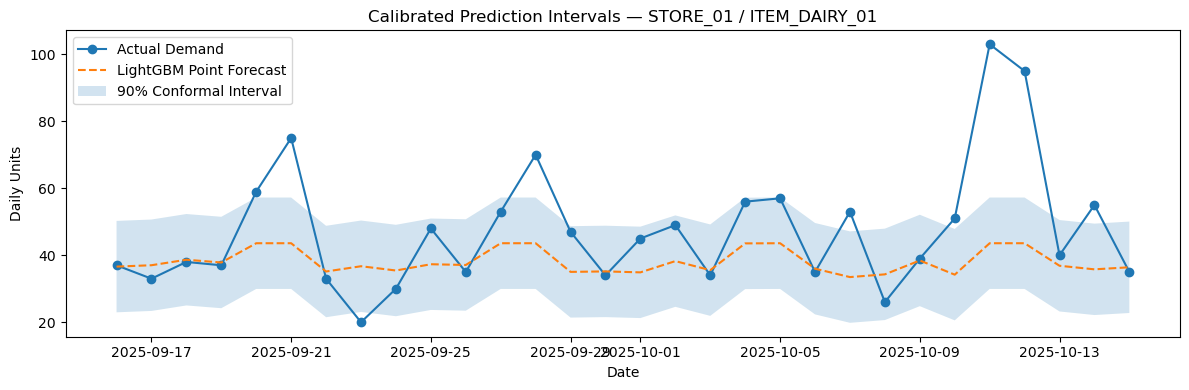

In [6]:
# Cell 6 — Visualize Conformal Interval for One Store-Item Pair

target_store = "STORE_01"
target_item = "ITEM_DAIRY_01"

sample_mask = (
    (X_test["store_id"] == target_store)
    & (X_test["item_id"] == target_item)
)

sample_indices = np.where(sample_mask.to_numpy())[0][:30]

if len(sample_indices) == 0:
    print(
        "The selected store-item pair was not present in the test set. "
        "Choose another pair from X_test."
    )
else:
    sub_X_arr = X_test_arr[sample_indices]
    sub_y = y_test.iloc[sample_indices].to_numpy()
    sub_dates = pd.to_datetime(
        X_test.iloc[sample_indices]["date"]
    )

    lower, yhat, upper = conformal.predict_interval(
        sub_X_arr,
        coverage=coverage_target,
    )

    plt.figure(figsize=(12, 4))
    plt.plot(
        sub_dates,
        sub_y,
        label="Actual Demand",
        marker="o",
    )
    plt.plot(
        sub_dates,
        yhat,
        label="LightGBM Point Forecast",
        linestyle="--",
    )
    plt.fill_between(
        sub_dates,
        lower,
        upper,
        alpha=0.20,
        label="90% Conformal Interval",
    )
    plt.title(
        f"Calibrated Prediction Intervals — "
        f"{target_store} / {target_item}"
    )
    plt.xlabel("Date")
    plt.ylabel("Daily Units")
    plt.legend()
    plt.tight_layout()
    plt.show()

## Step 3 — Stochastic supplier lead time

The generated metadata uses a probability distribution over lead times.

Example:

`2 days → 15%`, `3 days → 50%`, `5 days → 25%`, `7 days → 10%`

We combine those lead-time scenarios with the demand interval to simulate
Demand During Lead Time (DDLT).

In [7]:
# Cell 7 — Choose a Test Example and Obtain Its Interval

# Use the first available test row so the notebook is robust to the generated data.
example_idx = 0
example_X_arr = X_test_arr[[example_idx]]

example_lower, example_yhat, example_upper = conformal.predict_interval(
    example_X_arr,
    coverage=coverage_target,
)

point_forecast = float(example_yhat[0])
lower_day = float(example_lower[0])
upper_day = float(example_upper[0])

print("Example row:")
display(X_test.iloc[[example_idx]])

print(f"Point forecast: {point_forecast:.2f}")
print(f"Lower bound:    {lower_day:.2f}")
print(f"Upper bound:    {upper_day:.2f}")

Example row:


c:\Users\Bhavya\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


,date,store_id,item_id,category,on_promotion,base_price,unit_cost,shelf_life_days,holding_cost_per_day,spoilage_cost_per_unit,...,lag_14,lag_21,lag_28,rolling_mean_7,rolling_std_7,rolling_mean_14,rolling_std_14,rolling_mean_30,ratio_mean7_mean30,promo_in_next_3days
0,2025-09-16,STORE_01,ITEM_BAKERY_01,Bakery,0,50.07,33.44,3,0.94,40.08,...,11.0,25.0,9.0,16.285714,7.250616,16.642857,6.979168,17.6,0.925324,0


Point forecast: 18.97
Lower bound:    5.32
Upper bound:    32.61


In [8]:
# Cell 8 — Monte Carlo DDLT Simulation

example_item = X_test.iloc[example_idx]["item_id"]
lead_time_distribution = lead_time_meta = None

# Load the same lead-time metadata created by Notebook 1.
import json

metadata_path = ROOT / "data" / "raw" / "lead_time_metadata.json"

with open(metadata_path, "r", encoding="utf-8") as f:
    lead_time_metadata = json.load(f)

lt_dist = lead_time_metadata[str(example_item)]

print("Lead-time distribution for", example_item)
print(lt_dist)

max_horizon = max(int(k) for k in lt_dist.keys())

lower_bounds = np.repeat(
    max(0.0, lower_day),
    max_horizon,
)
upper_bounds = np.repeat(
    max(0.0, upper_day),
    max_horizon,
)

simulator = StochasticLeadTimeSimulator(
    lead_time_probs={int(k): float(v) for k, v in lt_dist.items()},
    lower_bounds=lower_bounds,
    upper_bounds=upper_bounds,
    random_state=RANDOM_SEED,
)

ddlt_samples, ddlt_summary = simulator.simulate_ddlt(
    num_simulations=10_000,
)

print("\nDDLT summary:")
display(pd.DataFrame([ddlt_summary]))

Lead-time distribution for ITEM_BAKERY_01
{'2': 0.13690237497839228, '3': 0.5109319534039872, '5': 0.2417833727042294, '7': 0.11038229891339094}

DDLT summary:


,mean,var,p90,p50
0,71.794364,1030.736934,119.184437,64.309841


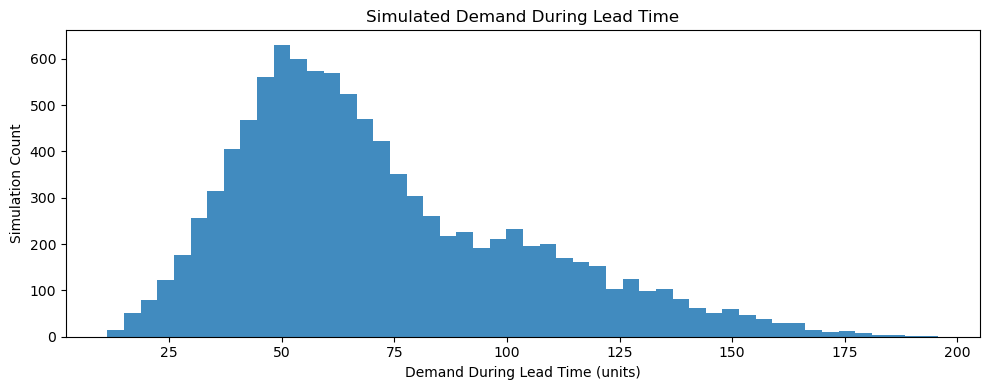

DDLT percentiles:


,value
count,10000.000000
mean,71.794364
std,32.106697
min,11.305355
50%,64.309841
90%,119.184437
95%,135.330116
99%,160.510189
max,195.818767


In [9]:
# Cell 9 — Visualize DDLT Distribution

plt.figure(figsize=(10, 4))
plt.hist(
    ddlt_samples,
    bins=50,
    alpha=0.85,
)
plt.title("Simulated Demand During Lead Time")
plt.xlabel("Demand During Lead Time (units)")
plt.ylabel("Simulation Count")
plt.tight_layout()
plt.show()

print("DDLT percentiles:")
display(
    pd.Series(ddlt_samples)
      .describe(percentiles=[0.50, 0.90, 0.95, 0.99])
      .to_frame("value")
)

## Step 4 — Perishable inventory cost model

The current optimizer supports:

- unit cost
- holding cost
- spoilage cost
- stockout cost
- shelf life
- current inventory

The current `evaluate_cost()` function uses:

**stockout cost + spoilage cost + holding cost**

The optimizer then searches for the order quantity that minimizes this expected cost.

In [10]:
# Cell 10 — Optimize Order Quantity

row = X_test.iloc[example_idx]

optimizer = PerishableInventoryOptimizer(
    unit_cost=float(row["unit_cost"]),
    holding_cost=float(row["holding_cost_per_day"]),
    spoilage_cost=float(row["spoilage_cost_per_unit"]),
    stockout_cost=float(row["stockout_cost_per_unit"]),
    shelf_life_days=int(row["shelf_life_days"]),
    current_inventory=15,
)

opt_result = optimizer.optimize_order_quantity(
    ddlt_samples,
    min_service_level=0.95,
)

print("Optimization output:")
for key, value in opt_result.items():
    if isinstance(value, (float, np.floating)):
        print(f"{key}: {value:.2f}")
    else:
        print(f"{key}: {value}")

Optimization output:
optimal_order_quantity: 120.79
inventory_after_order: 135.79
expected_total_cost: 973.10
service_level: 0.95
expected_shortage_units: 0.75
expected_leftover_units: 64.74
minimum_service_level: 0.95


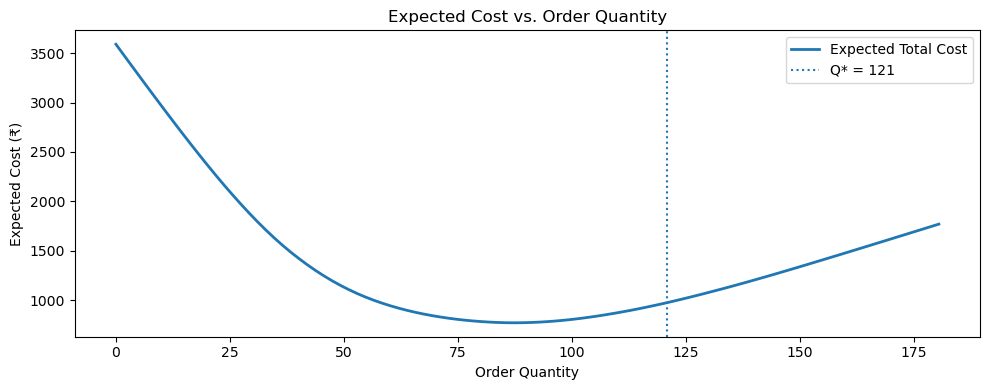

In [11]:
# Cell 11 — Cost vs Order Quantity

q_max = float(np.percentile(ddlt_samples, 99)) + 20
q_range = np.linspace(0, q_max, 100)

expected_costs = [
    optimizer.evaluate_cost(q, ddlt_samples)
    for q in q_range
]

optimal_q = opt_result["optimal_order_quantity"]

plt.figure(figsize=(10, 4))
plt.plot(
    q_range,
    expected_costs,
    linewidth=2,
    label="Expected Total Cost",
)
plt.axvline(
    optimal_q,
    linestyle=":",
    label=f"Q* = {optimal_q:.0f}",
)
plt.title("Expected Cost vs. Order Quantity")
plt.xlabel("Order Quantity")
plt.ylabel("Expected Cost (₹)")
plt.legend()
plt.tight_layout()
plt.show()

In [14]:
# Stress-test scenarios

scenarios = {
    "Baseline": ddlt_samples,
    "Demand +20%": ddlt_samples * 1.20,
    "Demand -20%": ddlt_samples * 0.80,
}

print("Scenarios created:")
for name, samples in scenarios.items():
    print(f"{name}: {len(samples):,} simulations")

Scenarios created:
Baseline: 10,000 simulations
Demand +20%: 10,000 simulations
Demand -20%: 10,000 simulations


In [15]:
stress_rows = []

for scenario_name, scenario_samples in scenarios.items():

    result = optimizer.optimize_order_quantity(
        scenario_samples,
        min_service_level=0.95,
    )

    stress_rows.append({
        "Scenario": scenario_name,
        "Optimal Order Qty": result["optimal_order_quantity"],
        "Achieved Service Level": result["service_level"],
        "Stockout Risk (%)": (1 - result["service_level"]) * 100,
        "Expected Shortage Units": result["expected_shortage_units"],
        "Expected Leftover Units": result["expected_leftover_units"],
        "Expected Total Cost": result["expected_total_cost"],
    })

stress_df = pd.DataFrame(stress_rows)

display(stress_df)

,Scenario,Optimal Order Qty,Achieved Service Level,Stockout Risk (%),Expected Shortage Units,Expected Leftover Units,Expected Total Cost
0,Baseline,120.787206,0.9514,4.86,0.748422,64.741264,973.100357
1,Demand +20%,147.905616,0.9513,4.87,0.900005,77.652384,1167.309425
2,Demand -20%,93.668797,0.9514,4.86,0.596841,51.830146,778.891423


In [16]:
print(opt_result)
print("\nAvailable keys:")
print(opt_result.keys())

{'optimal_order_quantity': 120.7872063940441, 'inventory_after_order': 135.78720639404412, 'expected_total_cost': 973.1003573110662, 'service_level': 0.9514, 'expected_shortage_units': 0.748422103015221, 'expected_leftover_units': 64.74126436367163, 'minimum_service_level': 0.95}

Available keys:
dict_keys(['optimal_order_quantity', 'inventory_after_order', 'expected_total_cost', 'service_level', 'expected_shortage_units', 'expected_leftover_units', 'minimum_service_level'])


## Notebook 3 — What you should understand

The final decision chain is:

**LightGBM point forecast**

↓

**Conformal uncertainty interval**

↓

**Stochastic supplier lead time**

↓

**Monte Carlo DDLT distribution**

↓

**Asymmetric inventory cost**

↓

**Order quantity recommendation**

### Important honesty point for interviews

The current optimizer accepts `min_service_level=0.95`, but the supplied
implementation does not enforce that threshold as a hard optimization constraint;
it reports the achieved service level after minimizing expected cost.

Do not claim the current code enforces a 95% service-level constraint until that
optimizer implementation is explicitly updated.